# Retry: 일시적 오류 재시도

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ksmin23/agent-pattern-examples/blob/feat/workflow-planning-colab/patterns/retry_or_fallback/examples/transient_error_retry/notebooks/retry_or_fallback-ko.ipynb)

**대상:** Python 함수와 async/await에 익숙한 Agent 입문자.

**학습 목표:** 재시도 정책 → 백오프 → 성공 또는 오류 전파 과정을 Agent 정의와 실행 셀로 직접 구성합니다.

**순서:** 환경 준비 → 입력·Agent 정의 → 실행 → 결과 확인 → 작은 실습.

소스 코드 · 예제 안내 · 환경 설정

### 패턴 구조

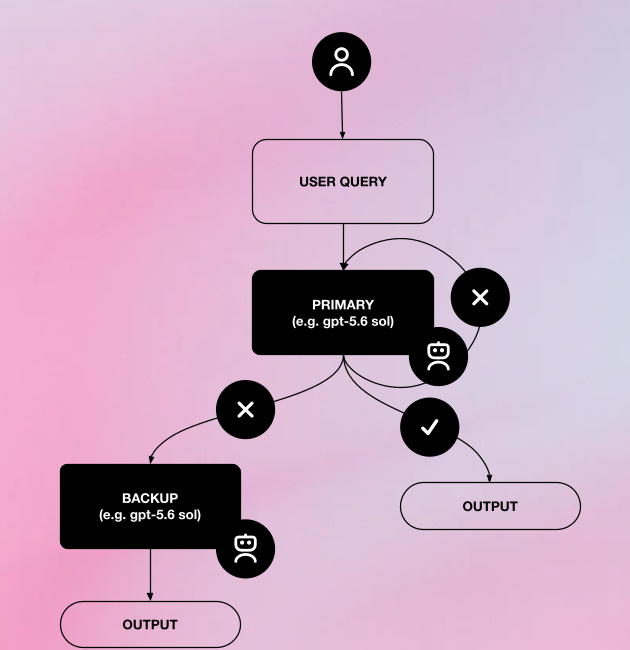

### 그림을 코드로 읽기

| 그림의 구성 요소 | 코드 구현 | 역할 |
| --- | --- | --- |
| User Query | `Runner.run(agent, ...)`의 입력 | Agent에 전달할 요청 |
| Primary | `agent` | 요청을 처리하는 기본 Agent |
| Retry policy | `ModelRetrySettings`와 `retry_policies` | 재시도할 오류와 횟수를 정의 |
| Failure | 첫 번째 mock HTTP 429 응답 | 일시적 오류를 재현 |
| Success Output | 두 번째 mock HTTP 200 응답 | 재시도 후 성공 결과 |
| Backup | 구현되지 않음 | 다른 모델이나 Agent로 전환하는 fallback |

#### 실행 흐름

1. `ModelRetrySettings`에 최대 재시도 횟수와 backoff 정책을 설정합니다.
2. 로컬 mock transport가 첫 요청에 HTTP 429를 반환합니다.
3. SDK가 정책에 따라 같은 모델 요청을 다시 실행합니다.
4. 두 번째 응답이 성공하면 결과를 반환합니다.

#### 그림과 이 예제의 차이

현재 Notebook은 일시적 오류에 대한 **retry만 구현**합니다. 그림의 Backup처럼 다른 모델이나 Agent로 전환하는 fallback은 포함하지 않습니다. fallback을 구현하려면 재시도 실패를 잡은 뒤 별도의 Agent 또는 모델을 실행하는 분기가 필요합니다.

## 1. 환경 준비

### Colab

1. 이 `.ipynb` 파일을 Colab의 **파일 → 노트북 업로드**로 엽니다. 저장소 복제나 Google Drive 마운트는 필요하지 않습니다. CPU 런타임으로 실행할 수 있습니다.
2. 아래 설정 셀이 `openai-agents==0.22.1`과 `python-dotenv`를 필요한 경우 설치합니다. 이미 다른 SDK 버전을 import했다면 런타임을 다시 시작한 뒤 위에서부터 실행하세요.
3. 실제 API 실행을 원하면 왼쪽 **Secrets(열쇠 아이콘)**에 기존 키를 `OPENAI_API_KEY` 이름으로 등록하고 이 Notebook의 접근 권한을 켭니다. 키를 코드 셀에 붙여넣지 마세요. 로컬 `.env.local`은 Colab에 자동 전달되지 않습니다.

### 로컬 Jupyter

`uv`로 공통 Notebook 환경을 설치한 뒤 해당 커널을 선택하세요. 기존 환경 변수를 우선 사용하며, 현재 위치 또는 상위 디렉터리에 `.env.local`이 있으면 추가 설정을 읽습니다. 오프라인 실습에는 `.env.local`이나 API 키가 필요하지 않습니다.

### 실행 설정

기본 `RUN_API=False`에서는 Secrets 조회와 API 호출 없이 Agent 구성과 오프라인 실습을 실행합니다. API 결과를 보려면 다음 셀에서 `RUN_API=True`로 변경하고 아래 셀을 순서대로 실행하세요. 키는 **환경 변수 → 선택적 `.env.local` → Colab Secrets** 순서로 찾으며 값을 출력하거나 파일에 저장하지 않습니다. 모델 호출 및 웹 검색에는 비용이 발생할 수 있습니다. Notebook에서는 `asyncio.run()` 대신 최상위 `await`를 사용합니다.

후반 독립 실행 예제는 별도의 `run_api=True` 인수로 활성화합니다. 앞부분의 `RUN_API` 변경은 이 인수에 적용되지 않습니다.


In [ ]:
import os
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

# Install only in Colab. Local environments use requirements-notebooks.txt.
try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    try:
        dependencies_ready = (
            version("openai-agents") == "0.22.1"
            and version("python-dotenv").split(".")[0] == "1"
        )
    except PackageNotFoundError:
        dependencies_ready = False
    if not dependencies_ready:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "--quiet",
            "openai-agents==0.22.1", "python-dotenv>=1,<2",
        ])

from agents import Agent, Runner, set_tracing_disabled
from dotenv import find_dotenv, load_dotenv


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


RUN_API = False  # Set True for the walkthrough's API and web search calls.
MODEL = load_environment(run_api=RUN_API)
set_tracing_disabled(True)
print({"environment": "Colab" if IN_COLAB else "local", "model": MODEL, "api_enabled": RUN_API})


## 2. SDK 재시도 정책

일시적인 HTTP 상태와 네트워크 오류만 재시도합니다. 최대 2회 재시도는 최초 호출을 포함해 최대 3번의 시도입니다.

In [ ]:
from agents import ModelRetrySettings, ModelSettings, retry_policies

retry = ModelRetrySettings(
    max_retries=2,
    backoff={
        "initial_delay": 0.1,
        "max_delay": 1.0,
        "multiplier": 2.0,
        "jitter": False,
    },
    policy=retry_policies.any(
        retry_policies.provider_suggested(),
        retry_policies.network_error(),
        retry_policies.http_status([408, 409, 429, 500, 502, 503, 504]),
    ),
)

agent = Agent(
    name="Resilient assistant",
    model=MODEL,
    instructions="Explain the answer in at most three short bullet points.",
    model_settings=ModelSettings(retry=retry),
)

## 3. 429 → 성공을 로컬에서 재현 · 실제 API 호출 없음

가짜 HTTP 전송 계층이 첫 요청에만 429를 반환합니다. OpenAI 클라이언트 자체의 재시도를 끄므로 SDK 정책에 의한 재시도를 확인할 수 있습니다.

In [ ]:
import httpx
from agents import OpenAIResponsesModel
from openai import AsyncOpenAI

attempts = 0


async def mock_response(request):
    global attempts
    attempts += 1

    if attempts == 1:
        return httpx.Response(
            429,
            json={
                "error": {"message": "Simulated rate limit", "type": "rate_limit_error"}
            },
        )

    return httpx.Response(
        200,
        json={
            "id": "resp_test",
            "object": "response",
            "created_at": 0,
            "model": MODEL,
            "status": "completed",
            "output": [
                {
                    "type": "message",
                    "id": "msg_test",
                    "role": "assistant",
                    "status": "completed",
                    "content": [
                        {
                            "type": "output_text",
                            "text": "Retry succeeded.",
                            "annotations": [],
                        }
                    ],
                }
            ],
            "usage": {"input_tokens": 1, "output_tokens": 1, "total_tokens": 2},
        },
    )


async with AsyncOpenAI(
    api_key="local-test-only",
    base_url="https://mock.invalid/v1",
    max_retries=0,
    http_client=httpx.AsyncClient(transport=httpx.MockTransport(mock_response)),
) as client:
    simulated = agent.clone(
        model=OpenAIResponsesModel(model=MODEL, openai_client=client)
    )
    simulated_result = await Runner.run(simulated, "Test retry", max_turns=2)

assert attempts == 2, f"Expected 2 attempts, got {attempts}"
assert simulated_result.final_output == "Retry succeeded."

print({"attempts": attempts, "result": simulated_result.final_output})

## 4. 실제 모델 실행 · API 호출

정상 호출에서 재시도 로그가 없는 것은 정상입니다. 위의 로컬 재현으로 오류 경로를 검증합니다.

In [ ]:
if RUN_API:
    result = await Runner.run(
        agent,
        "Explain exponential backoff in plain English.",
        max_turns=2,
    )

    assert str(result.final_output).strip()

    print(result.final_output)
else:
    print("Real API call skipped; the local HTTP 429 test is complete.")

## 5. 별도 파일로 구성하기: `main()` 실행 진입점

앞의 단계별 실습을 유지하면서, 같은 재시도 흐름을 하나의 Python 모듈로 구성합니다. 아래 함수 정의는 앞에서 만든 Agent나 전역 변수에 의존하지 않으므로, 필요한 패키지가 설치되어 있다면 이 코드 셀부터 실행할 수 있습니다.

**재시도 정책을 가진 Agent와 실행 함수를 구성하고, `main()`에서 환경 설정과 결과 출력을 담당합니다.** Python에서 전체 실행을 반복하는 대신 SDK가 모델 요청의 재시도를 처리합니다. 기존 실습과 마찬가지로 다른 모델로 전환하는 fallback은 포함하지 않습니다.

| 구성 | 책임 |
| --- | --- |
| `build_retry_settings()` | 재시도할 오류, 최대 횟수, backoff 설정 |
| `build_retry_agent()` | 재시도 정책을 적용한 Agent 구성 |
| `run_with_retry()` | Agent 실행과 최종 응답 반환 |
| `demonstrate_local_retry()` | 가짜 HTTP 전송 계층으로 429 → 성공 재현 |
| `main()` | 환경 설정, 로컬 검증, 선택적인 실제 API 호출, 결과 출력 |

함수 정의 셀만 실행하면 API를 호출하지 않습니다. `main()`은 기본적으로 로컬 재현만 실행하며, `run_api=True`로 지정하면 실제 API 호출도 추가로 실행합니다. 실제 호출에는 비용이 발생합니다. 재시도 상한 2회는 최초 요청을 포함해 최대 3번의 시도입니다.


In [ ]:
import asyncio
import os

import httpx
from agents import (
    Agent,
    ModelRetrySettings,
    ModelSettings,
    OpenAIResponsesModel,
    Runner,
    retry_policies,
    set_tracing_disabled,
)
from dotenv import find_dotenv, load_dotenv
from openai import AsyncOpenAI


def build_retry_settings() -> ModelRetrySettings:
    """Retry transient failures at most twice after the initial attempt."""
    return ModelRetrySettings(
        max_retries=2,
        backoff={
            "initial_delay": 0.1,
            "max_delay": 1.0,
            "multiplier": 2.0,
            "jitter": False,
        },
        policy=retry_policies.any(
            retry_policies.provider_suggested(),
            retry_policies.network_error(),
            retry_policies.http_status([408, 409, 429, 500, 502, 503, 504]),
        ),
    )


def build_retry_agent(model: str | OpenAIResponsesModel) -> Agent:
    """Configure an agent with the SDK retry policy."""
    return Agent(
        name="Resilient assistant",
        model=model,
        instructions="Explain the answer in at most three short bullet points.",
        model_settings=ModelSettings(retry=build_retry_settings()),
    )


async def run_with_retry(
    question: str,
    *,
    model: str | OpenAIResponsesModel,
) -> str:
    """Run one agent request; let the SDK handle retries and propagate failures."""
    agent = build_retry_agent(model)
    result = await Runner.run(agent, question, max_turns=2)

    return str(result.final_output)


async def demonstrate_local_retry(model: str) -> dict:
    """Reproduce HTTP 429 followed by success without network requests."""
    attempts = 0

    async def mock_response(request):
        nonlocal attempts
        attempts += 1

        if attempts == 1:
            return httpx.Response(
                429,
                json={
                    "error": {"message": "Simulated rate limit", "type": "rate_limit_error"}
                },
            )

        return httpx.Response(
            200,
            json={
                "id": "resp_test",
                "object": "response",
                "created_at": 0,
                "model": model,
                "status": "completed",
                "output": [
                    {
                        "type": "message",
                        "id": "msg_test",
                        "role": "assistant",
                        "status": "completed",
                        "content": [
                            {
                                "type": "output_text",
                                "text": "Retry succeeded.",
                                "annotations": [],
                            }
                        ],
                    }
                ],
                "usage": {"input_tokens": 1, "output_tokens": 1, "total_tokens": 2},
            },
        )

    async with AsyncOpenAI(
        api_key="local-test-only",
        base_url="https://mock.invalid/v1",
        max_retries=0,  # Test the SDK policy without client-level retries.
        http_client=httpx.AsyncClient(
            transport=httpx.MockTransport(mock_response)
        ),
    ) as client:
        output = await run_with_retry(
            "Test retry",
            model=OpenAIResponsesModel(model=model, openai_client=client),
        )

    assert attempts == 2, f"Expected 2 attempts, got {attempts}"
    assert output == "Retry succeeded."

    return {"attempts": attempts, "output": output}


def load_environment(*, run_api: bool) -> str:
    """Load optional local settings; request Colab Secrets only for live runs."""
    env_path = find_dotenv(filename=".env.local", usecwd=True)
    if env_path:
        load_dotenv(env_path, override=False)

    if run_api and not os.getenv("OPENAI_API_KEY", "").strip():
        try:
            from google.colab import userdata
        except ImportError:
            raise RuntimeError(
                "Set OPENAI_API_KEY in your environment or .env.local before enabling API calls."
            ) from None

        try:
            key = userdata.get("OPENAI_API_KEY")
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError, userdata.TimeoutException):
            raise RuntimeError(
                "In Colab Secrets, add OPENAI_API_KEY and enable Notebook access, "
                "then rerun this cell."
            ) from None
        if not isinstance(key, str) or not key.strip():
            raise RuntimeError("The OPENAI_API_KEY secret is empty.")
        os.environ["OPENAI_API_KEY"] = key.strip()

    return os.getenv("AGENT_MODEL", "gpt-5.6-luna")


async def main(
    question: str = "Explain exponential backoff in plain English.",
    *,
    run_api: bool = False,
) -> dict:
    """Load configuration, demonstrate retries locally, and optionally call the API."""
    model = load_environment(run_api=run_api)
    set_tracing_disabled(True)

    local_result = await demonstrate_local_retry(model)
    print("Local retry test:", local_result)

    result = {"local_test": local_result, "api_output": None}

    if not run_api:
        print("Real API call skipped. Pass run_api=True to enable it.")
        return result

    result["api_output"] = await run_with_retry(question, model=model)
    print(result["api_output"])

    return result


### Notebook에서 호출하기

Jupyter에서는 `asyncio.run()` 대신 `await main(...)`을 사용합니다. 아래 셀은 로컬 429 재현을 실행하고 실제 API 호출은 생략합니다. `.env.local`은 앞의 실습과 동일하게 현재 폴더 또는 상위 폴더에 필요하지만, 로컬 재현에는 실제 API 키가 필요하지 않습니다.

실제 모델도 실행하려면 `run_api=True`로 바꾸세요. 앞의 실습 결과를 재사용하지 않고 새로운 실행을 시작합니다.


In [ ]:
standalone_result = await main(
    question="Explain exponential backoff in plain English.",
    run_api=False,  # Run the local test only; set True to also call the API.
)


### `retry_agent.py` 파일로 실행하기

1. 위의 **함수 정의 코드 셀 전체**를 `retry_agent.py`에 복사합니다. Notebook 전용 `await main(...)` 호출 셀은 복사하지 않습니다.

2. 파일 맨 아래에 다음 진입점을 추가합니다. `--run-api`를 지정한 경우에만 실제 API를 호출합니다.

   ```python
   if __name__ == "__main__":
       import argparse

       parser = argparse.ArgumentParser(description="Demonstrate agent retries.")
       parser.add_argument("--run-api", action="store_true")
       args = parser.parse_args()

       asyncio.run(main(run_api=args.run_api))
   ```

3. 공통 실습 의존성이 설치된 가상환경을 활성화하고, 실행합니다. API 호출 시 환경 변수 또는 선택적 `.env.local`에 `OPENAI_API_KEY`를 설정합니다.

   ```bash
   python retry_agent.py            # Run only the local HTTP 429 reproduction
   python retry_agent.py --run-api  # Run the workflow; API costs apply
   ```

다른 모듈에서는 `from retry_agent import run_with_retry`로 가져와 `await run_with_retry(question, model=...)`을 호출합니다. 이 경우 환경 변수와 tracing 설정은 호출하는 애플리케이션에서 준비합니다. `if __name__ == "__main__":` 조건 때문에 import만으로 실행되지 않습니다.

로컬 재현 함수의 `attempts`는 함수 안에서 관리하므로 다시 실행할 때 0으로 초기화됩니다. OpenAI 클라이언트의 자체 재시도는 로컬 테스트에서 끄고 SDK 정책에 의한 재시도를 확인합니다. 실제 호출이 처음부터 성공하면 재시도가 발생하지 않는 것이 정상입니다. 재시도 대상이 아닌 오류나 재시도 상한을 넘긴 오류는 호출자에게 전달하며, 백업 Agent나 모델로 전환하지 않습니다.

이 추가 예제는 기존 `src/main.py`를 수정하거나 덮어쓰지 않습니다. 파일을 배포할 때는 이 Notebook의 출처와 저장소의 `THIRD_PARTY_NOTICES.md` 고지도 함께 유지하세요.


## 직접 바꿔보기

로컬 전송 계층의 첫 응답을 400으로 바꿔보세요. 재시도하지 않고 실패하는지 확인한 뒤 원래 429로 되돌리세요.

## 원본과 달라진 점 · 주의점

정책 구성을 간결하게 하고 가짜 HTTP 전송 계층을 추가했습니다. 백업 모델 전환은 구현하지 않습니다. 전체 워크플로를 재실행하는 방식이 아니며, 부작용 있는 도구의 중복 실행 방지는 별도 설계가 필요합니다.

## 출처

- [로컬 소스](../src/main.py)
- [OpenAI 공식 예제](https://github.com/openai/openai-agents-python/blob/25af629b3c877ba3d0e95189141bb636b21167a5/examples/basic/retry.py)
- [Agents SDK 가이드](https://developers.openai.com/api/docs/guides/agents/sdk)
- [Agents 가이드](https://developers.openai.com/api/docs/guides/agents)

이 Notebook은 공식 예제를 학습용으로 재구성한 파일이며 원본의 단순 복사본은 아닙니다. 모델 출력은 실행마다 달라집니다.